# Cardiovascular Disease — EDA & Model Training

## Dataset Description

**Source:** `cardio_train.csv` (separated by `;`)

The dataset contains **70,000 records** of patient data used to predict the presence or absence of cardiovascular disease.

### Features

| Feature | Description | Type |
|---------|-------------|------|
| `id` | Unique identifier | int |
| `age` | Age in days | int |
| `gender` | 1 = Female, 2 = Male | categorical |
| `height` | Height in cm | int |
| `weight` | Weight in kg | float |
| `ap_hi` | Systolic blood pressure | int |
| `ap_lo` | Diastolic blood pressure | int |
| `cholesterol` | 1 = Normal, 2 = Above Normal, 3 = Well Above Normal | categorical |
| `gluc` | 1 = Normal, 2 = Above Normal, 3 = Well Above Normal | categorical |
| `smoke` | Whether the patient smokes (0/1) | binary |
| `alco` | Whether the patient drinks alcohol (0/1) | binary |
| `active` | Whether the patient is physically active (0/1) | binary |
| **`cardio`** | **Target — Presence of cardiovascular disease (0/1)** | **binary** |

### Task
Binary classification — predict whether a patient has cardiovascular disease.

---
## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve
)

sns.set_theme(style='whitegrid')
%matplotlib inline

# Paths
DATA_DIR = os.path.join('..', 'data')
MODELS_DIR = os.path.join('..', 'models')

---
## 2. Load & Inspect the Data

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, 'cardio_train.csv'), sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [4]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# Check missing values
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Distribution

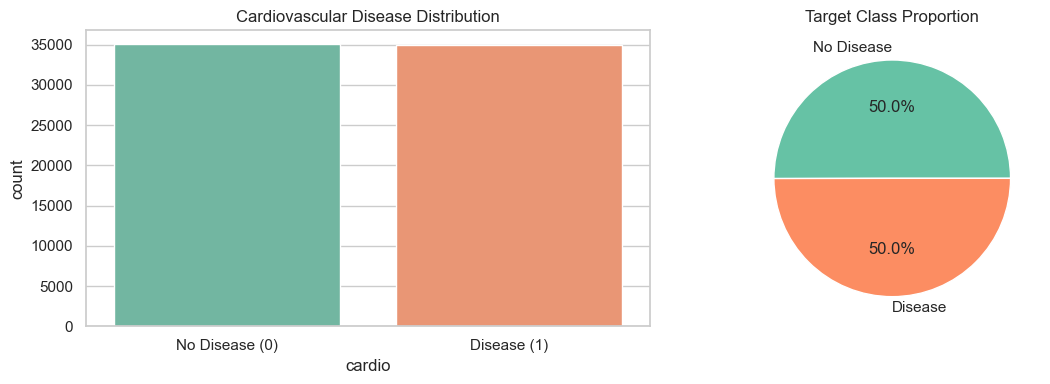

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='cardio', data=df, ax=ax[0], palette='Set2')
ax[0].set_title('Cardiovascular Disease Distribution')
ax[0].set_xticklabels(['No Disease (0)', 'Disease (1)'])

# Pie chart
df['cardio'].value_counts().plot.pie(autopct='%1.1f%%', labels=['No Disease', 'Disease'],
                                      colors=['#66c2a5','#fc8d62'], ax=ax[1])
ax[1].set_ylabel('')
ax[1].set_title('Target Class Proportion')

plt.tight_layout()
plt.show()

### 3.2 Age Distribution

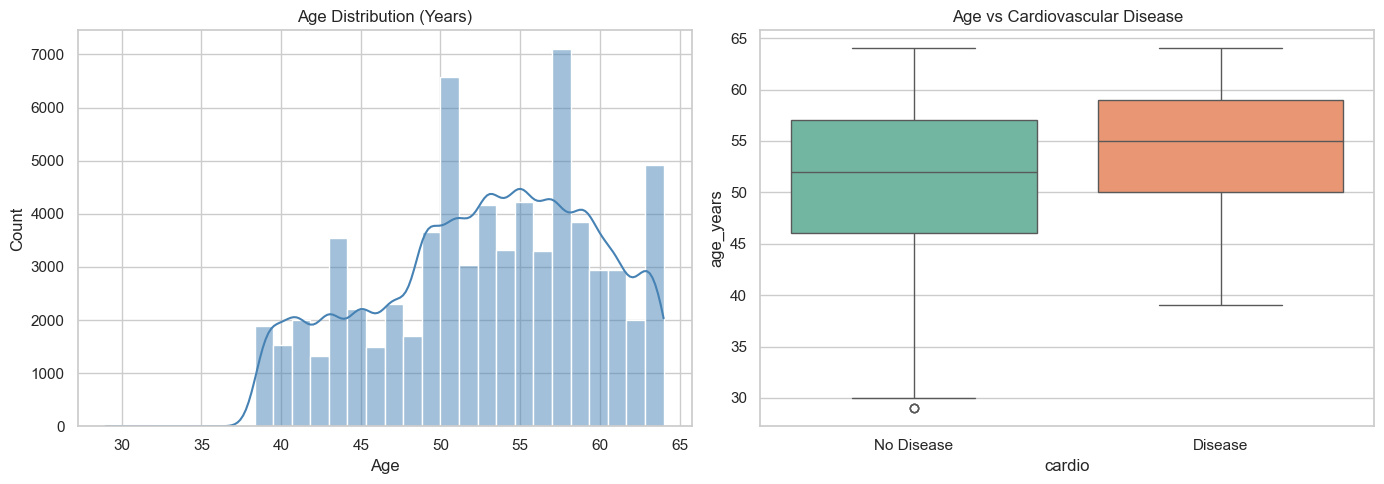

In [7]:
# Convert age from days to years
df['age_years'] = (df['age'] / 365.25).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['age_years'], bins=30, kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('Age Distribution (Years)')
ax[0].set_xlabel('Age')

sns.boxplot(x='cardio', y='age_years', data=df, ax=ax[1], palette='Set2')
ax[1].set_title('Age vs Cardiovascular Disease')
ax[1].set_xticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

### 3.3 Blood Pressure Analysis

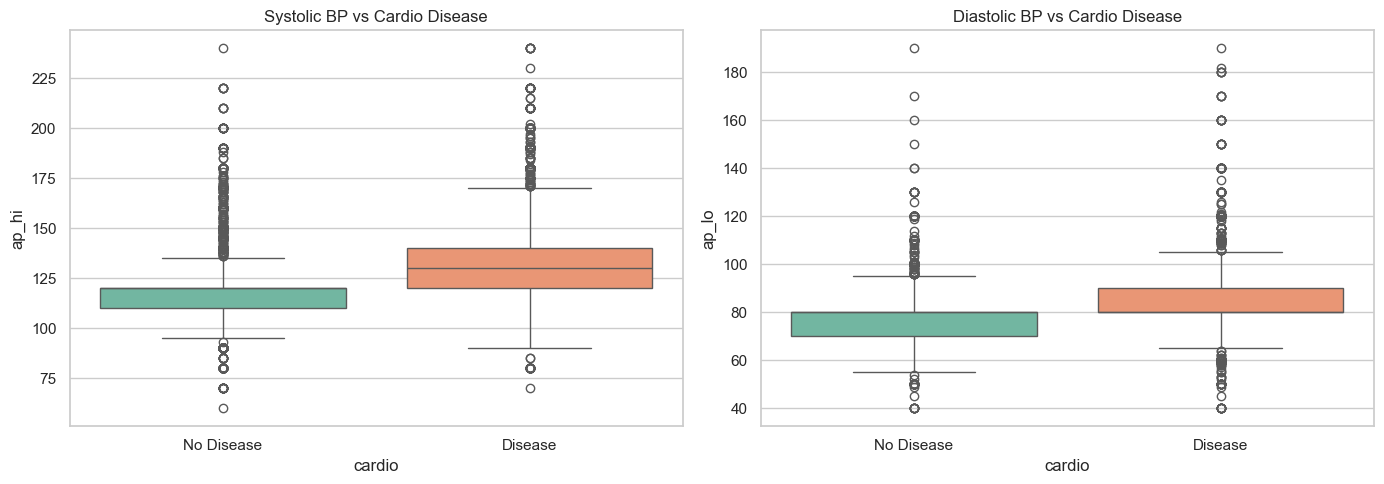

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter out extreme outliers for better visualization
bp_df = df[(df['ap_hi'] > 50) & (df['ap_hi'] < 250) & (df['ap_lo'] > 30) & (df['ap_lo'] < 200)]

sns.boxplot(x='cardio', y='ap_hi', data=bp_df, ax=axes[0], palette='Set2')
axes[0].set_title('Systolic BP vs Cardio Disease')
axes[0].set_xticklabels(['No Disease', 'Disease'])

sns.boxplot(x='cardio', y='ap_lo', data=bp_df, ax=axes[1], palette='Set2')
axes[1].set_title('Diastolic BP vs Cardio Disease')
axes[1].set_xticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

### 3.4 Categorical Features

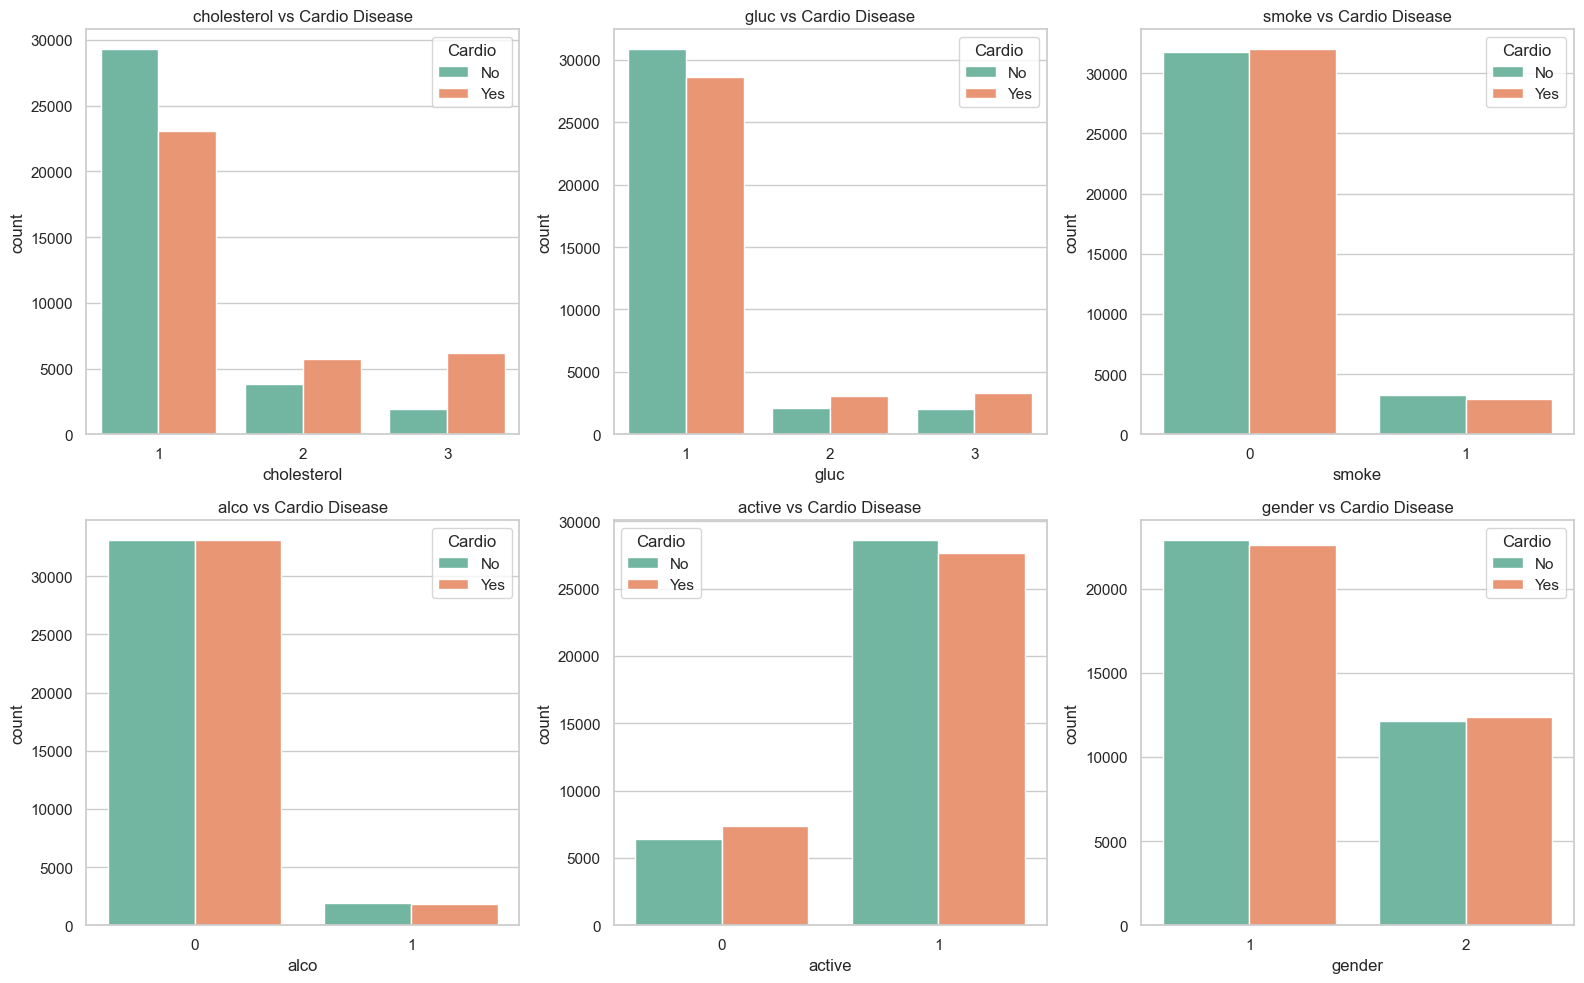

In [9]:
cat_features = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'gender']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(cat_features):
    ax = axes[i // 3, i % 3]
    sns.countplot(x=col, hue='cardio', data=df, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Cardio Disease')
    ax.legend(title='Cardio', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

### 3.5 Correlation Heatmap

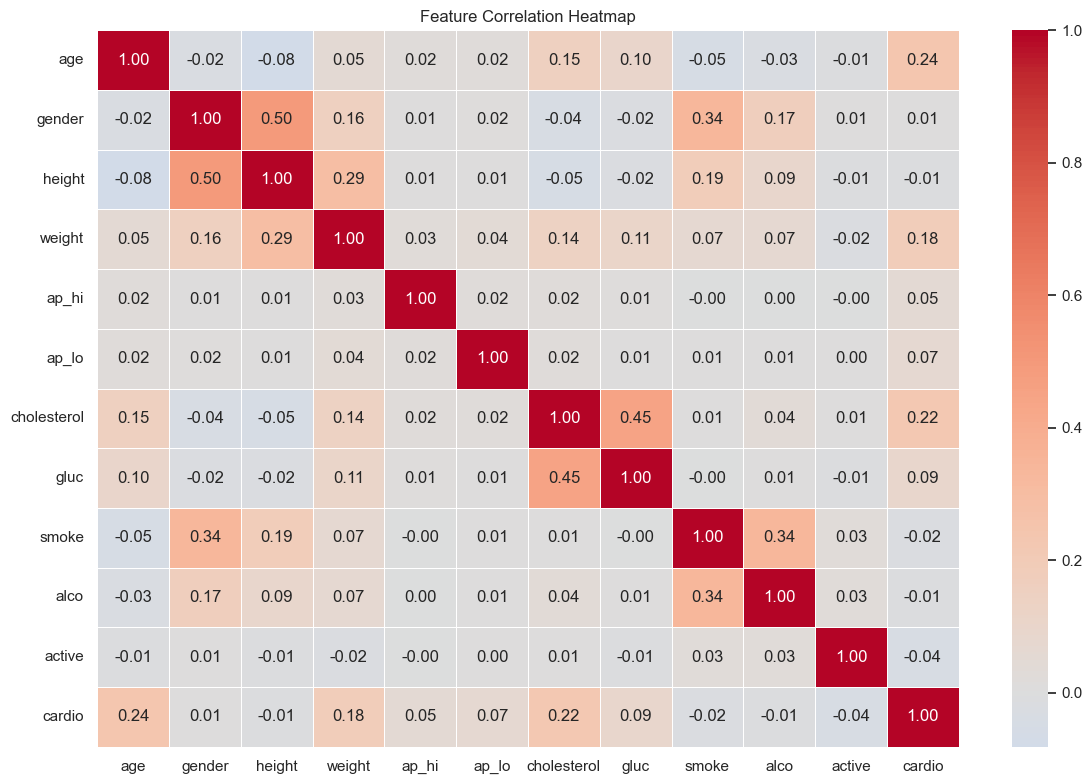

In [10]:
plt.figure(figsize=(12, 8))
corr = df.drop(columns=['id', 'age_years']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### 3.6 BMI Distribution

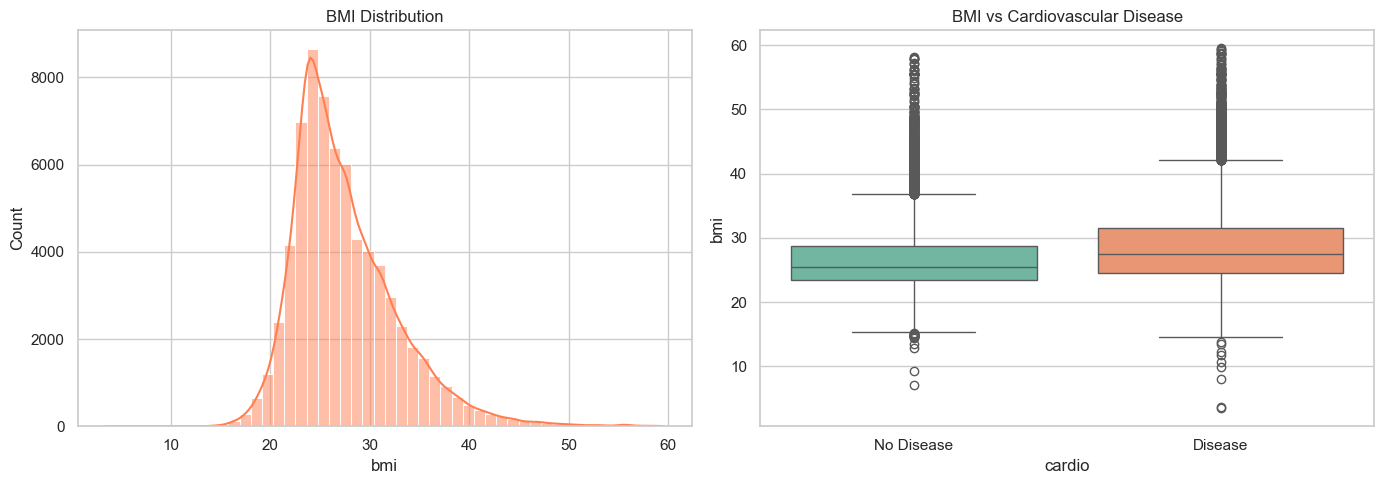

In [11]:
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df['bmi'] < 60]['bmi'], bins=50, kde=True, ax=ax[0], color='coral')
ax[0].set_title('BMI Distribution')

sns.boxplot(x='cardio', y='bmi', data=df[df['bmi'] < 60], ax=ax[1], palette='Set2')
ax[1].set_title('BMI vs Cardiovascular Disease')
ax[1].set_xticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing

In [12]:
# Reload clean copy for modeling
df_model = pd.read_csv(os.path.join(DATA_DIR, 'cardio_train.csv'), sep=';')
df_model.drop(columns=['id'], inplace=True)

X = df_model.drop('cardio', axis=1)
y = df_model['cardio']

print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (70000, 11)
Target distribution:
cardio
0    35021
1    34979
Name: count, dtype: int64


In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, os.path.join(MODELS_DIR, 'cardio_scaler.pkl'))

print(f'Train set: {X_train_scaled.shape}')
print(f'Test set:  {X_test_scaled.shape}')

Train set: (56000, 11)
Test set:  (14000, 11)


---
## 5. Model Training & Comparison

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=7, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=7, random_state=42, eval_metric='logloss', verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=7, random_state=42, verbose=-1),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'accuracy': acc, 'f1': f1, 'model': model}
    print(f'  Accuracy: {acc:.4f}  |  F1: {f1:.4f}')

Training Logistic Regression...
  Accuracy: 0.7136  |  F1: 0.7020
Training Random Forest...
  Accuracy: 0.7307  |  F1: 0.7123
Training Gradient Boosting...
  Accuracy: 0.7334  |  F1: 0.7229
Training XGBoost...
  Accuracy: 0.7340  |  F1: 0.7234
Training LightGBM...
  Accuracy: 0.7353  |  F1: 0.7255


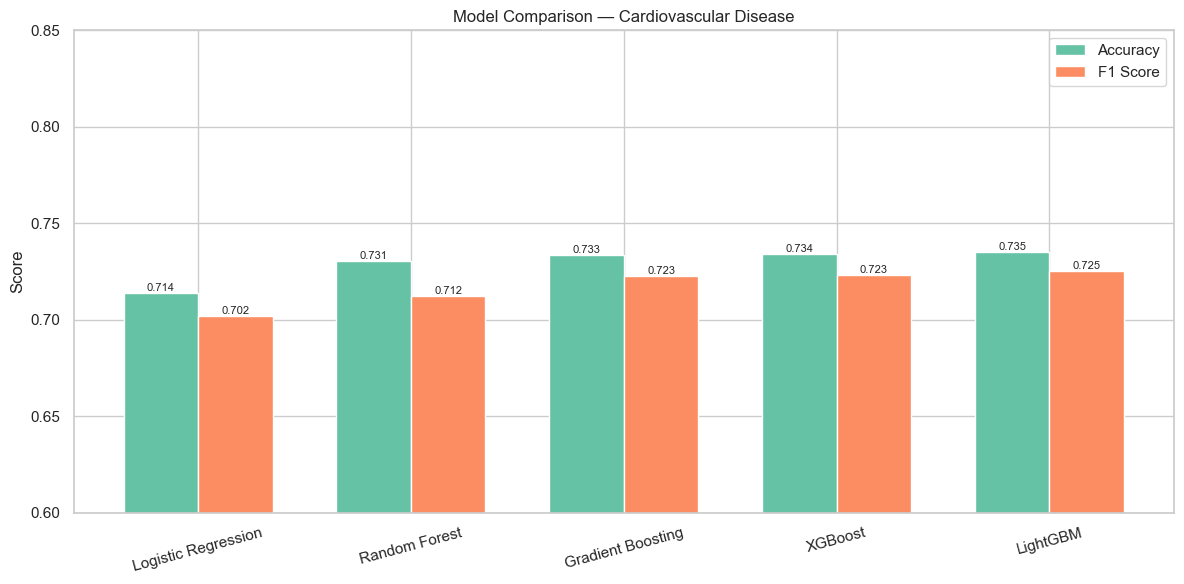

In [15]:
# Comparison bar chart
model_names = list(results.keys())
accuracies = [results[n]['accuracy'] for n in model_names]
f1_scores = [results[n]['f1'] for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#66c2a5')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='#fc8d62')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — Cardiovascular Disease')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.legend()
ax.set_ylim(0.6, 0.85)
ax.bar_label(bars1, fmt='%.3f', fontsize=8)
ax.bar_label(bars2, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()

---
## 6. Best Model — Detailed Evaluation

In [16]:
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_name]['model']
print(f'Best model: {best_name}')

y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

Best model: LightGBM

Accuracy:  0.7353
Precision: 0.7529
Recall:    0.7000
F1 Score:  0.7255
ROC-AUC:   0.7998

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      7004
           1       0.75      0.70      0.73      6996

    accuracy                           0.74     14000
   macro avg       0.74      0.74      0.73     14000
weighted avg       0.74      0.74      0.73     14000



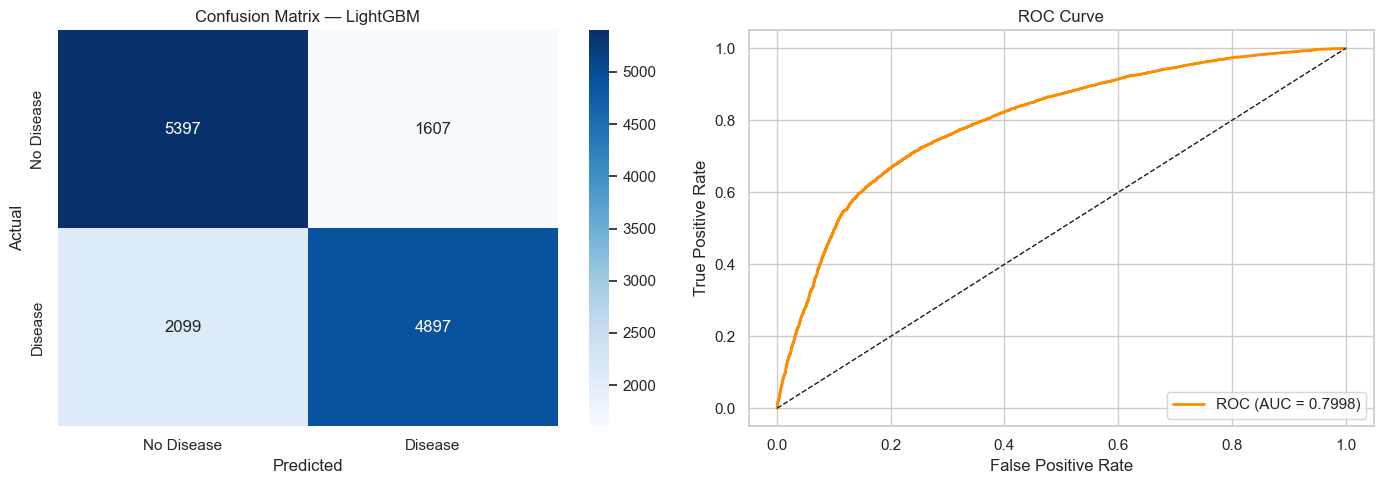

In [17]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[0].set_title(f'Confusion Matrix — {best_name}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

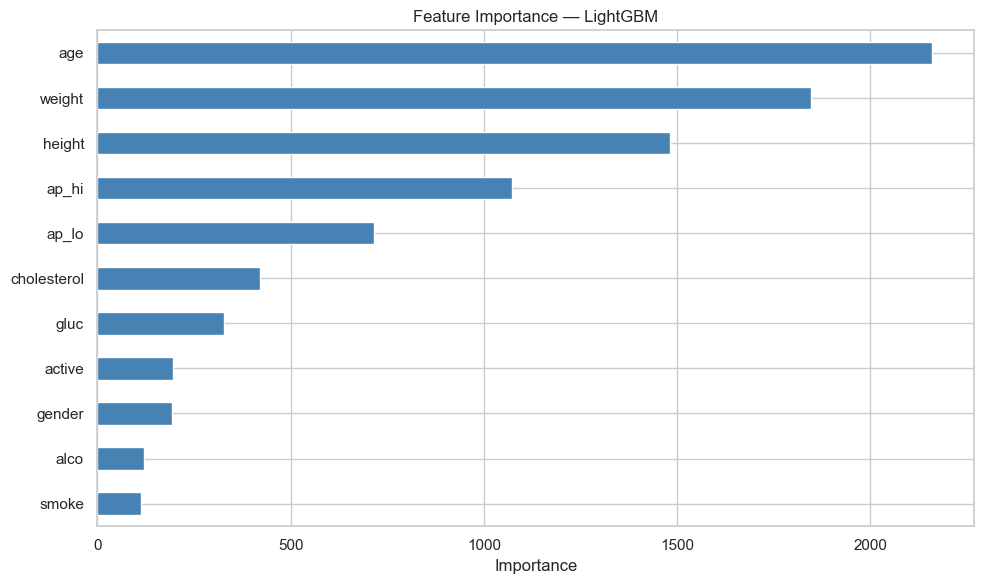

In [18]:
# Feature Importance (if tree-based model)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh', color='steelblue')
    plt.title(f'Feature Importance — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

---
## 7. Save Best Model

In [19]:
joblib.dump(best_model, os.path.join(MODELS_DIR, 'cardio_model.pkl'))
print(f'Best model ({best_name}) saved to models/cardio_model.pkl')
print(f'Scaler saved to models/cardio_scaler.pkl')

Best model (LightGBM) saved to models/cardio_model.pkl
Scaler saved to models/cardio_scaler.pkl
